# Week 1: Listing Remarks Exploration

Goal: understand how agents write listing remarks, and check how well the taxonomy covers them.

Data: `data/processed/listing_sample.csv` (1,000 random California residential listings from `rets_property`).

Raw remarks are not printed here so the notebook is safe to commit. Only counts and charts are shown.

In [1]:
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from scripts.taxonomy_builder import compile_matchers, load_taxonomy, match_terms, normalize, top_ngrams

pd.set_option("display.max_colwidth", 60)
df = pd.read_csv(ROOT / "data/processed/listing_sample.csv")
df.shape

(1000, 7)

## 1. The listings

In [2]:
df[["beds", "baths", "price"]].describe().round(1)

,beds,baths,price
count,996.0,1000.0,1000.0
mean,3.3,2.8,1468937.5
std,1.3,1.5,2786175.3
min,0.0,0.0,45000.0
25%,2.0,2.0,538000.0
50%,3.0,3.0,815730.0
75%,4.0,3.0,1369750.0
max,11.0,16.0,48888000.0


In [3]:
# Prices under $20k are monthly rents, not sale prices
likely_rentals = df["price"] < 20_000
print(f"Likely rental listings: {likely_rentals.sum()} of {len(df)}")

Likely rental listings: 0 of 1000


In [4]:
df["L_City"].value_counts().head(10)

L_City
Los Angeles     80
San Diego       43
San Jose        22
Palm Springs    14
Menifee         13
Palm Desert     13
Long Beach      13
Riverside       11
Malibu          10
Indio           10
Name: count, dtype: int64

## 2. Remark length

In [5]:
df["n_chars"] = df["remarks"].str.len()
df["n_words"] = df["remarks"].str.split().str.len()
df[["n_chars", "n_words"]].describe().round(0)

,n_chars,n_words
count,1000.0,1000.0
mean,1344.0,202.0
std,582.0,85.0
min,138.0,24.0
25%,954.0,145.0
50%,1278.0,191.0
75%,1704.0,255.0
max,4000.0,576.0


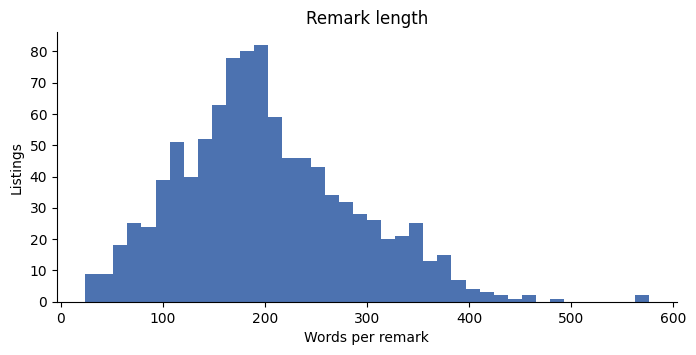

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(df["n_words"], bins=40, color="#4C72B0")
ax.set_xlabel("Words per remark")
ax.set_ylabel("Listings")
ax.set_title("Remark length")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 3. Most common words and phrases

Stopwords are removed so the real estate vocabulary stands out.

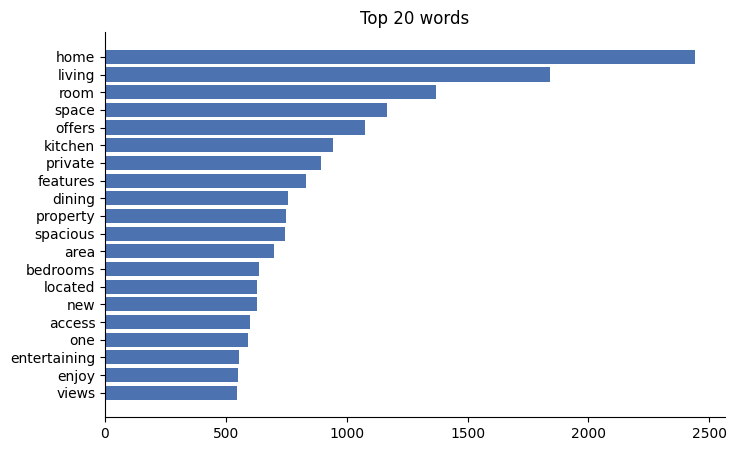

In [7]:
def ngram_table(n, k=20):
    rows = [(" ".join(g), c) for g, c in top_ngrams(df["remarks"], n, k)]
    return pd.DataFrame(rows, columns=["phrase", "count"])

words = ngram_table(1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(words["phrase"][::-1], words["count"][::-1], color="#4C72B0")
ax.set_title("Top 20 words")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [8]:
pd.concat([ngram_table(2).add_prefix("bigram_"), ngram_table(3).add_prefix("trigram_")], axis=1)

,bigram_phrase,bigram_count,trigram_phrase,trigram_count
0,primary suite,335,stainless steel appliances,158
1,floor plan,327,conveniently located near,109
2,living room,313,living and entertaining,108
3,living space,306,abundant natural light,82
4,home offers,280,plenty of room,80
5,natural light,266,approximately square feet,78
6,walk-in closet,200,living and dining,77
7,stainless steel,187,spacious primary suite,76
8,dining area,179,additional highlights include,73
9,everyday living,177,pool and spa,70


## 4. Writing patterns

Share of remarks that contain each pattern. These tell us what the text cleaning and entity extraction steps will need to handle.

In [9]:
# (pattern, case_sensitive)
PATTERNS = {
    "bed/bath counts (3 bed, 2-bath)": (r"\b\d+(?:\.\d)?\s*-?\s*(?:bed|bath|br|ba|bd)", False),
    "square footage (1,850 sq ft)": (r"\d[\d,]*\s*(?:sq\.?\s*ft|sqft|square feet|sf\b)", False),
    "dollar amounts ($14,000)": (r"\$\s?\d", False),
    "year built (built in 1985)": (r"\b(?:built|constructed)\b[^.]{0,20}\b(?:19|20)\d{2}\b", False),
    "abbreviations (HOA, ADU, LVP)": (r"\b(?:hoa|adu|lvp|hvac|rv|ev)\b", False),
    "exclamation marks": (r"!", False),
    "ALL CAPS words (4+ letters)": (r"\b[A-Z]{4,}\b", True),
    "line breaks": (r"\n", False),
    "phone numbers": (r"\(?\d{3}\)?[\s.-]\d{3}[\s.-]\d{4}", False),
    "web links": (r"https?://|www\.", False),
}

def share(pattern, case_sensitive):
    flags = 0 if case_sensitive else re.IGNORECASE
    return df["remarks"].str.contains(pattern, regex=True, flags=flags).mean()

patterns = pd.Series({name: share(*p) for name, p in PATTERNS.items()})
(patterns.sort_values(ascending=False) * 100).round(1).astype(str) + "%"

bed/bath counts (3 bed, 2-bath)    57.2%
exclamation marks                  41.4%
abbreviations (HOA, ADU, LVP)      36.3%
square footage (1,850 sq ft)       34.1%
ALL CAPS words (4+ letters)        29.0%
line breaks                        25.0%
dollar amounts ($14,000)            7.4%
year built (built in 1985)          7.2%
web links                           0.5%
phone numbers                       0.2%
dtype: object

## 5. Taxonomy coverage

In [10]:
taxonomy = load_taxonomy()
matchers = compile_matchers(taxonomy)
df["terms"] = df["remarks"].apply(lambda r: match_terms(r, matchers))
df["n_terms"] = df["terms"].str.len()

remark_coverage = (df["n_terms"] > 0).mean()
found_ids = {t["id"] for terms in df["terms"] for t in terms}
term_coverage = len(found_ids) / len(taxonomy["terms"])

print(f"Taxonomy terms:                  {len(taxonomy['terms'])}")
print(f"Remarks with at least one term:  {remark_coverage:.1%}")
print(f"Taxonomy terms found in sample:  {term_coverage:.1%}")
print(f"Median terms per remark:         {df['n_terms'].median():.0f}")

Taxonomy terms:                  260
Remarks with at least one term:  100.0%
Taxonomy terms found in sample:  96.9%
Median terms per remark:         19


In [11]:
rows = []
for category, desc in taxonomy["categories"].items():
    cat_terms = [t for t in taxonomy["terms"] if t["category"] == category]
    mentioned = df["terms"].apply(lambda ts: any(t["category"] == category for t in ts))
    rows.append({
        "category": category,
        "terms": len(cat_terms),
        "terms found in sample": sum(t["id"] in found_ids for t in cat_terms),
        "% of remarks mentioning": round(mentioned.mean() * 100, 1),
    })
by_category = pd.DataFrame(rows).set_index("category").sort_values("% of remarks mentioning", ascending=False)
by_category

,terms,terms found in sample,% of remarks mentioning
category,,,
rooms_layout,38,38,96.2
exterior_lot,32,32,93.8
interior_systems,42,42,83.4
location_views,31,31,75.1
condition_sale,35,35,74.3
community_amenities,27,27,54.6
architectural_style,27,22,51.5
property_type,28,25,29.7


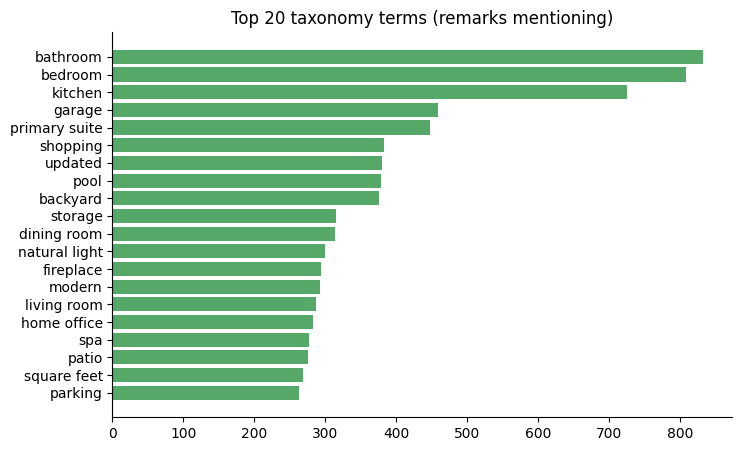

In [12]:
term_counts = Counter(t["term"] for terms in df["terms"] for t in terms)
top = pd.DataFrame(term_counts.most_common(20), columns=["term", "remarks"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["term"][::-1], top["remarks"][::-1], color="#55A868")
ax.set_title("Top 20 taxonomy terms (remarks mentioning)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [13]:
# Terms that never appear in this sample
missing = [t for t in taxonomy["terms"] if t["id"] not in found_ids]
pd.DataFrame(missing)[["id", "term", "category"]]

,id,term,category
0,PT021,patio home,property_type
1,PT027,tract home,property_type
2,PT028,twin home,property_type
3,AS007,tuscan,architectural_style
4,AS016,french country,architectural_style
5,AS019,minimalist,architectural_style
6,AS025,a-frame,architectural_style
7,AS027,mission style,architectural_style


## 6. Key findings

**I. Remark content**

*Remarks have plenty of detail, but a lot of it is marketing filler.*
- About 190 words per remark
- Mostly rooms and layout (primary suite, floor plan, walk-in closet)
- Common filler phrases ("home offers", "rare opportunity") to filter out

**II. Extraction targets**

*Key facts are often written in the text, so we can extract them and check them against the database columns.*
- Bed/bath counts in 57% of remarks
- Square footage in 34%
- Dollar amounts and year built in about 7%

**III. Challenges**

*The text needs cleaning and context before we can match terms reliably.*
- Exclamation marks in 41%, ALL CAPS words in 29%
- Terms with more than one meaning ("spa" can be a hot tub or a spa-like bathroom)
- Wide price range ($45k to $48.9M) that needs outlier handling

**IV. Taxonomy coverage**

*The taxonomy fits the data well and easily passes the 30% target.*
- 100% of remarks match at least one term
- 97% of the 260 terms appear in the sample
- Property type (30%) and style (52%) show up least, since agents usually put these in structured fields